In [12]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
import json, IPython, re
import requests

In [13]:
class AgentState(TypedDict):
    text : str
    classification : list
    icdcodes : list
    medicines : list

In [14]:
def vertexAI_endpint(context, context_length, SYSTEM_PROMPT):

    try:
        url = "http://172.16.36.10:9006/generate" 

        payload = json.dumps({
        "context": context,
        "context_length": context_length,
        "SYSTEM_PROMPT": SYSTEM_PROMPT
        })
        
        headers = {
        'Content-Type': 'application/json'
        }

        response = requests.request("POST", url, headers=headers, data=payload,timeout=120)
        #print(json.loads(response.text)['result'])
        return json.loads(response.text)['result']

    except Exception as e:
        print(e)

In [ ]:

 
def classification(state: AgentState):
    try:
        Classification_instructions = """
        You are a medical document classification engine.

        TASK:
        Determine whether the provided text contains:
        - ICD codes (with "ICD-10-CM" or "ICD-9-CM")
        - Medication (with "tablet" or "mg")

        Return ONLY a valid JSON list:

        ["ICD CODE"]
        ["Medication"]
        ["ICD CODE","Medication"]
        []

        Do not return anything else.
        """

        raw_output = vertexAI_endpint(
            state["text"],
            1024,
            Classification_instructions
        )

        print("RAW OUTPUT class:", raw_output)

        # ---------------------------
        # Clean markdown wrapping
        # ---------------------------
        if isinstance(raw_output, str) and raw_output.startswith("```"):
            raw_output = raw_output.strip("`")
            raw_output = raw_output.replace("json", "", 1).strip()

        # ---------------------------
        # Parse JSON safely
        # ---------------------------
        try:
            parsed = json.loads(raw_output)
        except json.JSONDecodeError:
            cleaned = re.sub(r",\s*([\]}])", r"\1", raw_output)
            try:
                parsed = json.loads(cleaned)
            except Exception:
                parsed = []

        # ---------------------------
        # Normalize output (VERY IMPORTANT)
        # ---------------------------
        if not isinstance(parsed, list):
            parsed = []

        normalized = [str(item).strip().upper() for item in parsed]

        # Optional: filter only allowed values
        allowed = {"ICD CODE", "MEDICATION"}
        normalized = [item for item in normalized if item in allowed]

        return {
            "classification": normalized
        }

    except Exception as e:
        return {
            "classification": []
        }

In [16]:
def route_from_classification(state: AgentState):
    cls = state.get("classification", [])

    routes = []

    if "ICD CODE" in cls:
        routes.append("icd_extraction")

    if "MEDICATION" in cls:
        routes.append("medic_extractor")

    if not routes:
        return "none"

    return routes 

In [17]:
def icdextractor(state: AgentState) :
    text = state["text"]

    icd_pattern = r"\bICD[-\s]?(?:10|9)[-\s]?CM\b.*?\b[A-Z0-9.]+\b"

    matches = re.findall(icd_pattern, text, re.IGNORECASE)
    print(f"icd codes :{matches}")

    return {
        "icdcodes":matches
    }

In [18]:
def medicextractor(state: AgentState):
    try:
        extraction_instructions = """
        You are a medication extraction engine.

        TASK:
        Extract all medicine names from the text.

        Medicine names are usually followed by:
        "mg", "MG", "tablet", "TABLET", etc.

        Return ONLY a valid JSON list:

        ["medicine1","medicine2",...]

        Do not return anything else.
        """

        raw_output = vertexAI_endpint(
            state["text"],
            1024,
            extraction_instructions
        )

        print("RAW OUTPUT medic:", raw_output)

        # ---------------------------
        # Clean markdown
        # ---------------------------
        if isinstance(raw_output, str) and raw_output.startswith("```"):
            raw_output = raw_output.strip("`")
            raw_output = raw_output.replace("json", "", 1).strip()

        # ---------------------------
        # Parse JSON safely
        # ---------------------------
        try:
            parsed = json.loads(raw_output)
        except json.JSONDecodeError:
            cleaned = re.sub(r",\s*([\]}])", r"\1", raw_output)
            try:
                parsed = json.loads(cleaned)
            except Exception:
                parsed = []

        # ---------------------------
        # Normalize output
        # ---------------------------
        if not isinstance(parsed, list):
            parsed = []

        normalized = [str(item).strip() for item in parsed]

        # Optional: remove duplicates
        normalized = list(dict.fromkeys(normalized))

        return {
            "medicines": normalized
        }

    except Exception as e:
        return {
            "medicines": [],
        }

In [19]:
graph = StateGraph(AgentState)

# Nodes
graph.add_node("classification", classification)
graph.add_node("icd_codes_extractor", icdextractor)
graph.add_node("medication_extractor", medicextractor)


# Flow start
graph.add_edge(START, "classification")

# Conditional routing
graph.add_conditional_edges(
    "classification",
    route_from_classification,
    {
        "icd_extraction": "icd_codes_extractor",
        "medic_extractor": "medication_extractor",
        "none": END
    }
)

app=graph.compile()


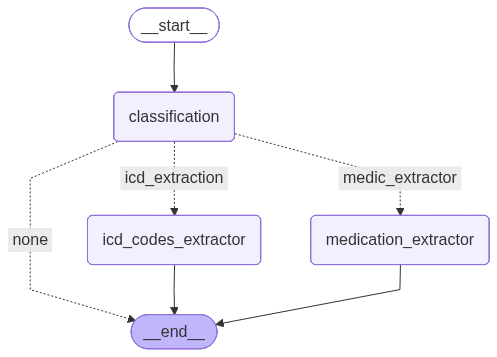

In [20]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [25]:
inputjson= r"20049.json"

with open(inputjson,'r') as f:
    inputtext=json.load(f)

all_text=inputtext["texts"]
page_num=3
page=page_num-1
test_page=all_text[page]
test_page

"OLSC PRV PRIMARY CARE  Melvin, William F\n1541 Kings Hwy   MRN: 14458325,DOB: 9/24/1948, Legal Sex: M\nSHREVEPORT LA 71103-4228  Acct #; 28009157410\nEnc. Date 10/9/2024\n10/09/2024 Office Visit in Shreveport-Provenance Primary Care (continued)\nMedications the Patient Reported Taking (continued_\nDisp Refills Start End\nmesalamine (CANASA) 1000 MG Supp (Taking) 90 suppository 4/8/2024\nSig: Place 1 suppository (1,000 mg total) rectally nightly:\nRoute: Rectal\nrosuvastatin (CRESTOR) 40 MG Tab (Taking) 90 tablet  4/8/2024\nSig: Take 1 tablet (40 mg total) by mouth once daily:\nRoute: Oral\nSITagliptan-metformin (JANUMET) 50-1,000 mg per 180 tablet 3 4/16/2024 4/16/2025\ntablet (Taking)\nSig: Take tablet by mouth 2 (two) times daily with meals:\nRoute: Oral\nProgress Notes\nProgress Notes by Callegan-Poche_Amanda LMD at 10/9/2024 8:15 AM\nAuthor: Callegan-Poche, Amanda L. MD Service:  Author Type: Physician\nFiled: 10/9/2024 1:17 PM Encounter Date: 10/9/2024 Creation Time: 10/9/2024 8.

In [26]:
result = app.invoke({"text":test_page})
print(json.dumps(result, indent=4))

RAW OUTPUT class: ["Medication"]

RAW OUTPUT medic: ```json
["mesalamine","rosuvastatin","SITagliptan-metformin","JANUMET","Jardiance"]
```
{
    "text": "OLSC PRV PRIMARY CARE  Melvin, William F\n1541 Kings Hwy   MRN: 14458325,DOB: 9/24/1948, Legal Sex: M\nSHREVEPORT LA 71103-4228  Acct #; 28009157410\nEnc. Date 10/9/2024\n10/09/2024 Office Visit in Shreveport-Provenance Primary Care (continued)\nMedications the Patient Reported Taking (continued_\nDisp Refills Start End\nmesalamine (CANASA) 1000 MG Supp (Taking) 90 suppository 4/8/2024\nSig: Place 1 suppository (1,000 mg total) rectally nightly:\nRoute: Rectal\nrosuvastatin (CRESTOR) 40 MG Tab (Taking) 90 tablet  4/8/2024\nSig: Take 1 tablet (40 mg total) by mouth once daily:\nRoute: Oral\nSITagliptan-metformin (JANUMET) 50-1,000 mg per 180 tablet 3 4/16/2024 4/16/2025\ntablet (Taking)\nSig: Take tablet by mouth 2 (two) times daily with meals:\nRoute: Oral\nProgress Notes\nProgress Notes by Callegan-Poche_Amanda LMD at 10/9/2024 8:15

In [27]:
import time

def process_ocr_pages_to_json(pages, output_json_path):
    all_results = []

    total_start_time = time.time()   

    for page_num, text in enumerate(pages, start=1):
        page_start_time = time.time()   

        try:
            if not text or not text.strip():
                print(f"Page {page_num}: Empty, skipping")
                continue

            print(f"Processing Page {page_num}/{len(pages)}...")

            # Run your LangGraph app
            result = app.invoke({"text": text})

            page_end_time = time.time()

            page_result = {
                "page_number": page_num,
                "processing_time_sec": round(page_end_time - page_start_time, 3),
                "result": result
            }

            all_results.append(page_result)

            print(f"Page {page_num} done in {round(page_end_time - page_start_time, 3)} sec")

        except Exception as e:
            page_end_time = time.time()

            print(f"Error on page {page_num}: {e}")

            all_results.append({
                "page_number": page_num,
                "processing_time_sec": round(page_end_time - page_start_time, 3),
                "error": str(e)
            })

    total_end_time = time.time()

    total_time = round(total_end_time - total_start_time, 3)

    # Save to JSON
    output_data = {
        "total_pages": len(pages),
        "total_processing_time_sec": total_time,
        "pages": all_results
    }

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(output_data, f, indent=4, ensure_ascii=False)

    print(f"\n Results saved to {output_json_path}")
    print(f" Total processing time: {total_time} sec")

output_path =r"output12page.json"

process_ocr_pages_to_json(all_text, output_path)



Processing Page 1/12...
RAW OUTPUT class: ["ICD CODE"]

icd codes :['ICD-10-CM: E78.5', 'ICD-9-CM: 272.4', 'ICD-10-CM: E11.29', 'ICD-9-CM: 250.40', 'ICD-10-CM: Z86.19', 'ICD-9-CM: V12.09', 'ICD-10-CM: E11.9', 'ICD-9-CM: 250.00', 'ICD-10-CM: Z86.0100', 'ICD-9-CM: V12.72', 'ICD-10-CM: D17.20', 'ICD-9-CM: 214.1', 'ICD-10-CM: L98.8', 'ICD-9-CM: 709.8', 'ICD-10-CM: E13.21', 'ICD-9-CM: 249.40', 'ICD-10-CM: BOO.50', 'ICD-9-CM: 054.40', 'ICD-10-CM: K57.90', 'ICD-9-CM: 562.10', 'ICD-10-CM: E78.5', 'ICD-9-CM: 272.4', 'ICD-10-CM: /10', 'ICD-9-CM: 401.9', 'ICD-10-CM: K51.30', 'ICD-9-CM: 556.2', 'ICD-10-CM: H93.13', 'ICD-9-CM: 388.30']
Page 1 done in 0.995 sec
Processing Page 2/12...
RAW OUTPUT class: ["ICD CODE","Medication"]

icd codes :[]
RAW OUTPUT medic: ```json
["aspirin","cetirizine","empagliflozin","ezetimibe","fosinopriL","gabapentin","glipiZIDE","mesalamine","rosuvastatin","SlTagliptan-metformin"]
```
Page 2 done in 2.145 sec
Processing Page 3/12...
RAW OUTPUT class: ["Medication"]

RAW O